In [1]:
from data_prep import *

import os
import pandas as pd

from sklearn.model_selection import train_test_split

In [2]:
data_abs_path = r"C:\Users\jason\Desktop\Storm Damage Analsis - Storm Level\data_wrangling\merged_data"

parent_dat = None
for folder in os.listdir(data_abs_path):
    for file in os.listdir(os.path.join(data_abs_path, folder)):
        if file.endswith('.csv'):
            dat = pd.read_csv(os.path.join(data_abs_path, folder, file))
            if parent_dat is None:
                parent_dat = dat
            else:
                parent_dat = pd.concat([parent_dat, dat], ignore_index=True)

predicting if a storm will be damaging

In [3]:
from logregress import *

In [4]:
prepped_data = prep_data(parent_dat, drop_zeros=False).dropna()

prepped_data

,BEGIN_LAT,BEGIN_LON,STORM_AREA_SQMILES,DURATION_MINUTES,TEMPERATURE_F,ANOMALY_F,RONI_AVG,POPULATION,MEDIAN_INCOME,MEDIAN_YEAR_BUILT,...,MODAL_YEAR_BUILT_BIN_built_1970_to_1979,MODAL_YEAR_BUILT_BIN_built_1980_to_1989,MODAL_YEAR_BUILT_BIN_built_1990_to_1999,MODAL_YEAR_BUILT_BIN_built_2000_to_2009,MODAL_YEAR_BUILT_BIN_built_2010_to_2019,MODAL_YEAR_BUILT_BIN_built_2020_or_later,COASTAL_TYPE_SHORELINE_inland,COASTAL_TYPE_SHORELINE_shoreline,COASTAL_TYPE_WATERSHED_inland,COASTAL_TYPE_WATERSHED_watershed
2,34.5824,-96.9700,0.000000,1,57.1,-6.6,0.933333,12729.0,39989.0,1972.0,...,0,0,1,0,0,0,1,0,1,0
3,34.0000,-81.0200,0.421161,90,44.6,-1.3,0.666667,359144.0,47969.0,1979.0,...,0,1,0,0,0,0,1,0,1,0
4,34.0800,-81.1800,24.230614,45,44.2,-1.2,0.666667,244348.0,51983.0,1984.0,...,0,0,0,1,0,0,1,0,1,0
5,34.0950,-80.9706,7.178050,45,44.6,-1.3,0.666667,359144.0,47969.0,1979.0,...,0,1,0,0,0,0,1,0,1,0
6,34.7200,-80.7700,763.766480,75,43.6,-0.7,0.666667,58176.0,45035.0,1985.0,...,0,0,0,1,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
580319,41.5700,-79.2700,0.000000,0,66.4,2.5,-0.433333,6715.0,52191.0,1970.0,...,1,0,0,0,0,0,1,0,1,0
580320,40.3700,-79.5000,0.000000,0,69.7,2.2,-0.433333,352500.0,74109.0,1964.0,...,0,0,0,0,0,0,1,0,1,0
580321,40.3800,-79.4900,0.000000,71,69.7,2.2,-0.433333,352500.0,74109.0,1964.0,...,0,0,0,0,0,0,1,0,1,0
580322,40.5171,-79.8231,0.025913,60,71.5,3.1,-0.433333,1238177.0,78548.0,1957.0,...,0,0,0,0,0,0,1,0,1,0


In [5]:
X = prepped_data.drop(columns=['DAMAGE_PROPERTY'])
y = prepped_data['DAMAGE_PROPERTY']

# change y to be 1 if damage > 0 and 0 if damage == 0
y = (prepped_data['DAMAGE_PROPERTY'] > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.25, random_state=8)

log = train_logreg(X_train, X_test, y_train, y_test, seed=8)

Train Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.80      0.77    219390
           1       0.64      0.57      0.60    138116

    accuracy                           0.71    357506
   macro avg       0.69      0.68      0.69    357506
weighted avg       0.71      0.71      0.71    357506

Test Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.80      0.77     73295
           1       0.64      0.57      0.60     45874

    accuracy                           0.71    119169
   macro avg       0.69      0.68      0.69    119169
weighted avg       0.70      0.71      0.71    119169

Test ROC AUC: 0.7534


c:\miniconda\envs\damage\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [6]:
from xgboost_classifier import *

In [7]:
xgclass = tune_log_model(X_train, X_test, y_train, y_test, seed=8, n_iter=30)

CV log loss:  0.3160
best params:  {'colsample_bytree': np.float64(0.8802360769246469), 'gamma': np.float64(0.6463017545913169), 'learning_rate': np.float64(0.25369526054916236), 'max_depth': 7, 'min_child_weight': 19, 'n_estimators': 1116, 'reg_alpha': np.float64(9.461569778662378), 'reg_lambda': np.float64(0.38188862184074057), 'subsample': np.float64(0.6108121060583478)}
holdout ROC AUC:    0.9361
holdout PR  AUC:    0.9087
holdout log loss:   0.3101
holdout Brier:      0.0949
holdout accuracy:   0.8699


In [8]:
from perm_importance import *
perm_imp_train, perm_imp_test = get_perm_importance(X_train, y_train, X_test, y_test, xgclass)

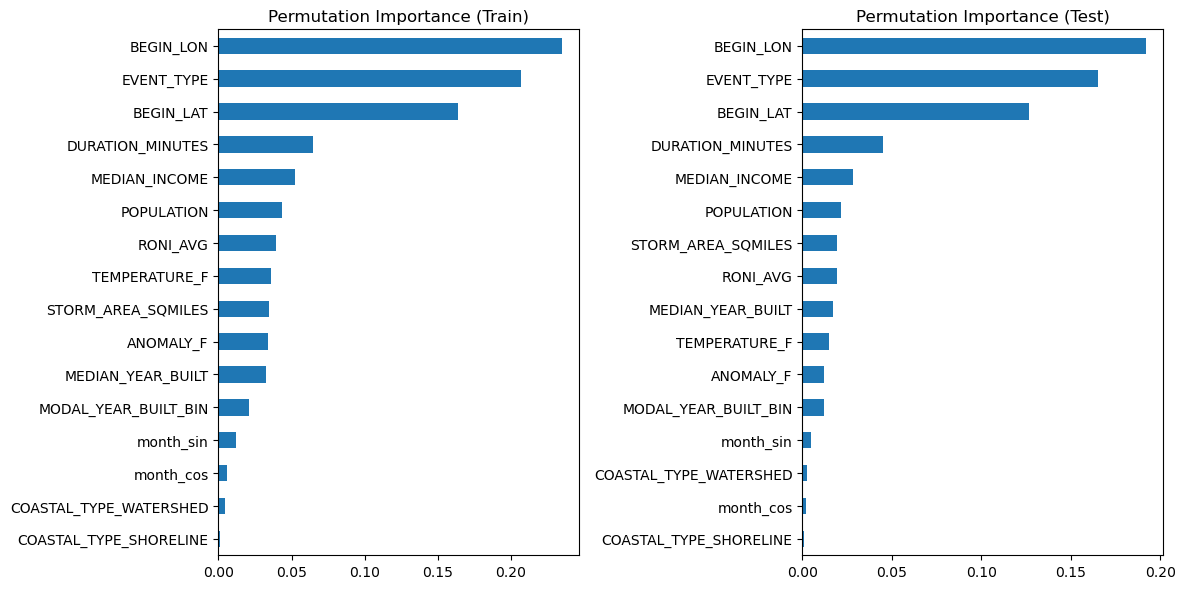

In [9]:
# plot the permutation importance for train and test sets
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

perm_imp_train.plot(kind='barh', ax=ax[0], title='Permutation Importance (Train)')
perm_imp_test.plot(kind='barh', ax=ax[1], title='Permutation Importance (Test)')

plt.tight_layout()
plt.show()

Predicting the damage of damaging storms 

In [10]:
from xgboost_regress import *

In [11]:
prepped_nonZero_data = prep_data(parent_dat).dropna()
    
prepped_nonZero_data

,BEGIN_LAT,BEGIN_LON,STORM_AREA_SQMILES,DURATION_MINUTES,TEMPERATURE_F,ANOMALY_F,RONI_AVG,POPULATION,MEDIAN_INCOME,MEDIAN_YEAR_BUILT,...,MODAL_YEAR_BUILT_BIN_built_1970_to_1979,MODAL_YEAR_BUILT_BIN_built_1980_to_1989,MODAL_YEAR_BUILT_BIN_built_1990_to_1999,MODAL_YEAR_BUILT_BIN_built_2000_to_2009,MODAL_YEAR_BUILT_BIN_built_2010_to_2019,MODAL_YEAR_BUILT_BIN_built_2020_or_later,COASTAL_TYPE_SHORELINE_inland,COASTAL_TYPE_SHORELINE_shoreline,COASTAL_TYPE_WATERSHED_inland,COASTAL_TYPE_WATERSHED_watershed
3,34.0000,-81.0200,0.421161,90,44.6,-1.3,0.666667,359144.0,47969.0,1979.0,...,0,1,0,0,0,0,1,0,1,0
4,34.0800,-81.1800,24.230614,45,44.2,-1.2,0.666667,244348.0,51983.0,1984.0,...,0,0,0,1,0,0,1,0,1,0
5,34.0950,-80.9706,7.178050,45,44.6,-1.3,0.666667,359144.0,47969.0,1979.0,...,0,1,0,0,0,0,1,0,1,0
6,34.7200,-80.7700,763.766480,75,43.6,-0.7,0.666667,58176.0,45035.0,1985.0,...,0,0,0,1,0,0,1,0,0,1
7,34.7200,-80.7700,763.766480,75,42.6,-1.6,0.666667,23482.0,32120.0,1977.0,...,0,0,0,1,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
580270,40.3894,-79.8080,1.472851,3,71.5,3.1,-0.433333,1238177.0,78548.0,1957.0,...,0,0,0,0,0,0,1,0,1,0
580271,40.4269,-80.3060,0.029395,1,70.7,2.7,-0.433333,210042.0,78958.0,1966.0,...,1,0,0,0,0,0,1,0,1,0
580274,40.1754,-81.8500,0.000000,0,70.9,2.6,-0.433333,36744.0,55577.0,1967.0,...,1,0,0,0,0,0,1,0,1,0
580280,39.7769,-80.1302,0.001539,2,70.0,1.9,-0.433333,34835.0,68041.0,1960.0,...,1,0,0,0,0,0,1,0,1,0


In [12]:
X = prepped_nonZero_data.drop(columns=['log10_damage'])
y = prepped_nonZero_data['log10_damage']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=8)

xgbregress = tune_model(X_train, X_test, y_train, y_test, n_iter=50)

CV RMSE: 0.6166
best params: {'colsample_bytree': np.float64(0.876201218034711), 'gamma': np.float64(0.31625638277172186), 'learning_rate': np.float64(0.037245155512243826), 'max_depth': 8, 'min_child_weight': 3, 'n_estimators': 784, 'reg_alpha': np.float64(0.5456957318755907), 'reg_lambda': np.float64(3.453872469197429), 'subsample': np.float64(0.8937150517432543)}
Train RMSE: 0.5162
Test RMSE: 0.6050
Test R2:   0.4985


In [13]:
from perm_importance import *
perm_imp_train, perm_imp_test = get_perm_importance(X_train, y_train, X_test, y_test, xgbregress)

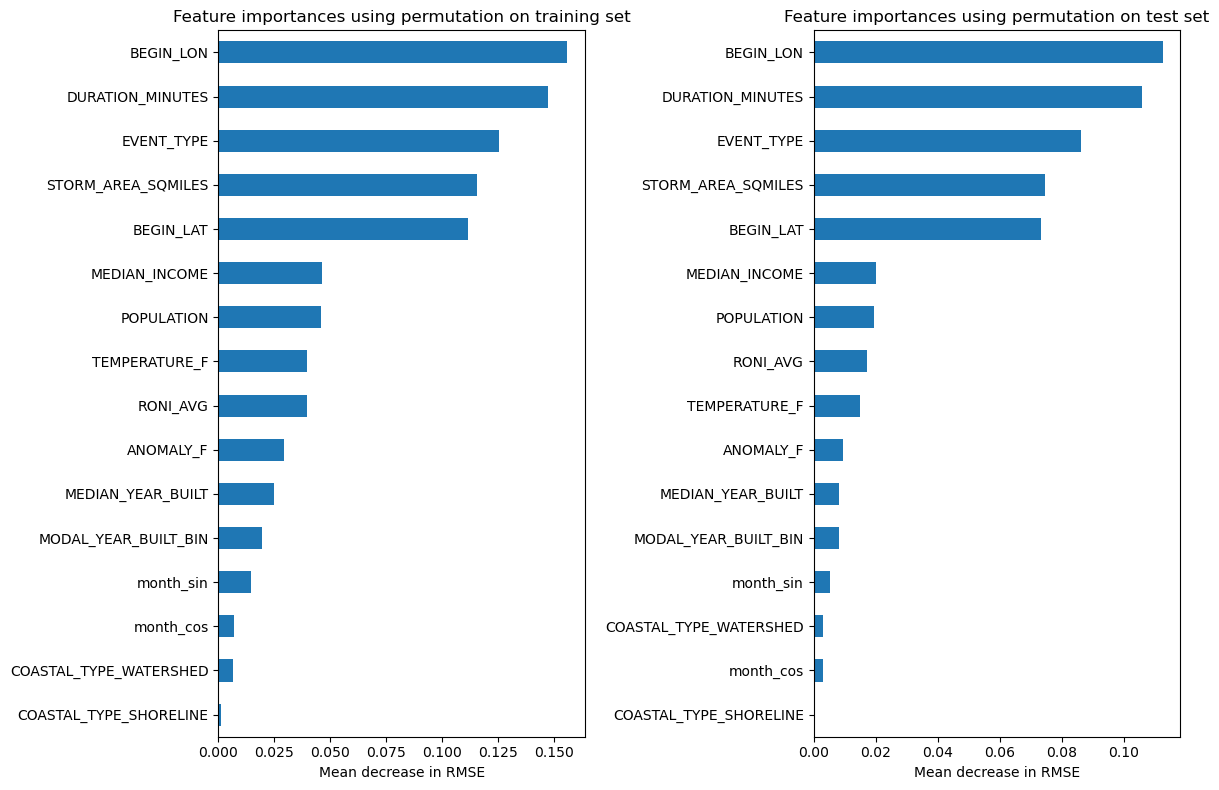

In [14]:
# plot the permutation importance for the test set and train set side by side
fig, (ax1, ax2) = plt.subplots(1,2 , figsize=(12, 8))

perm_imp_train.plot.barh(ax=ax1)
ax1.set_title("Feature importances using permutation on training set")
ax1.set_xlabel("Mean decrease in RMSE")

perm_imp_test.plot.barh(ax=ax2)
ax2.set_title("Feature importances using permutation on test set")
ax2.set_xlabel("Mean decrease in RMSE")

plt.tight_layout()
plt.show()